<a href="https://colab.research.google.com/github/jmompou/03-MIAR-Algoritmos-de-Optimizacion/blob/main/Algoritmos_AG2JorgeIbanezPuertas(no_borrar).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Actividad Guiada 1 de Algoritmos de Optimizacion


Nombre: Jorge Ibáñez Puertas

https://colab.research.google.com/drive/1jLOBwBwz54BKEHkyiAoqut40kicvnsmx?usp=sharing (Mi cuaderno)

https://github.com/jmompou/03-MIAR-Algoritmos-de-Optimizacion (Proyecto git)

1.   Elemento de lista
2.   Elemento de lista



#Torres de Hanoi - Divide y venceras
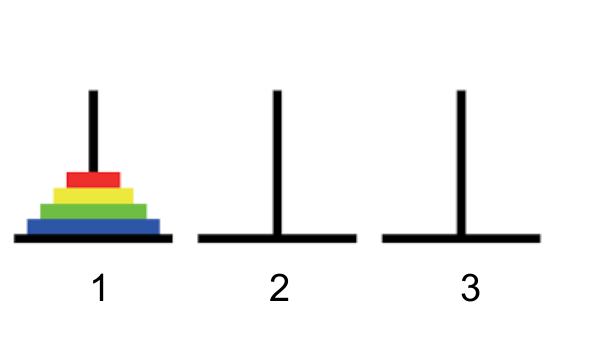

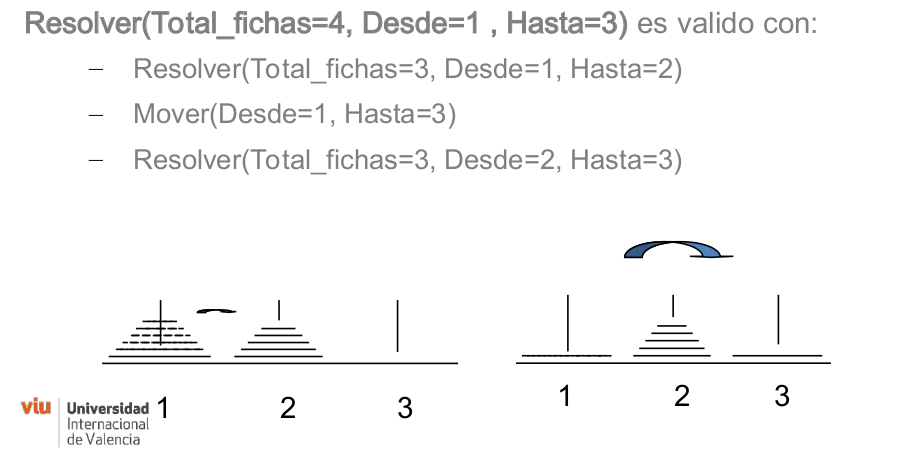

In [49]:
#Torres de Hanoi - Divide y venceras
################################################################################


################################################################
def Resolver(N, desde, hasta):
  #N - Nº de fichas
  #desde - torre inicial
  #hasta - torre fina
  if N==1 :
    print("Lleva la ficha desde " + str(desde) + " hasta " + str(hasta))

  else:
    Resolver(N-1, desde, 6-desde-hasta)
    print("Lleva la ficha desde " + str(desde) + " hasta " + str(hasta))
    Resolver(N-1, 6-desde-hasta,  hasta)

Resolver(3, 1, 3)
################################################################

Lleva la ficha desde 1 hasta 3
Lleva la ficha desde 1 hasta 2
Lleva la ficha desde 3 hasta 2
Lleva la ficha desde 1 hasta 3
Lleva la ficha desde 2 hasta 1
Lleva la ficha desde 2 hasta 3
Lleva la ficha desde 1 hasta 3


#Cambio de monedas - Técnica voraz #AG2#

In [50]:
#Cambio de monedas - Técnica voraz
################################################################################
SISTEMA = [11,5,1] #Definimos un conjunto con los valores de las monedas disponibles
#Parece ccrucial que deben aparecer en esa lista en orden de mayor a menor para que
#funcione correctamente el algoritmo.
#SComentario: en la clase hemos visto de utilizar SISTEMA.sort(reverse=TRUE)
#pero eso devuelve None, yo creo que mejor así SISTEMA_ORDENADO = sorted(SISTEMA, reverse=True),
#esto si ordena nuestra lista bien.
################################################################
def cambio_monedas(CANTIDAD,SISTEMA):
#....
  SOLUCION = [0]*len(SISTEMA) #Esto crea lo que los matemáticos llamamos un vector nulo, aquí sería de R3 (0,0,0)
  #de R3 debido a la longitud de la lista SISTEMA. Esta nos sirve como base para ir anotando
  #cuántas monedas usaremos
  ValorAcumulado = 0

  for i,valor in enumerate(SISTEMA):
    monedas = (CANTIDAD-ValorAcumulado)//valor
    SOLUCION[i] = monedas
    ValorAcumulado = ValorAcumulado + monedas*valor

    if CANTIDAD == ValorAcumulado:
      return SOLUCION

  print("No es posible encontrar solucion")
cambio_monedas(15,SISTEMA)


################################################################

[1, 0, 4]

#N Reinas - Vuelta Atrás(Backtracking)
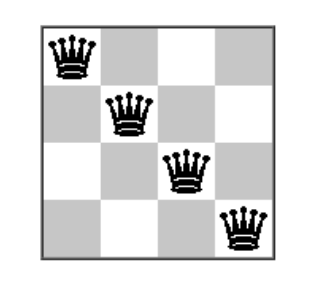

In [51]:
#N Reinas - Vuelta Atrás()
################################################################################

#Verifica que en la solución parcial no hay amenzas entre reinas
################################################################
def es_prometedora(SOLUCION,etapa):
################################################################
  #print(SOLUCION)
  #Si la solución tiene dos valores iguales no es valida => Dos reinas en la misma fila
  for i in range(etapa+1):
    #print("El valor " + str(SOLUCION[i]) + " está " +  str(SOLUCION.count(SOLUCION[i])) + " veces")
    if SOLUCION.count(SOLUCION[i]) > 1:
      return False

    #Verifica las diagonales
    for j in range(i+1, etapa +1 ):
      #print("Comprobando diagonal de " + str(i) + " y " + str(j))
      if abs(i-j) == abs(SOLUCION[i]-SOLUCION[j]) : return False
  return True

#Traduce la solución al tablero
################################################################
def escribe_solucion(S):
################################################################
  n = len(S)
  for x in range(n):
    print("")
    for i in range(n):
      if S[i] == x+1:
        print(" X " , end="")
      else:
        print(" - ", end="")



#Proceso principal de N-Reinas
################################################################
def reinas(N, solucion=[],etapa=0):
################################################################
### ....
  if len(solucion) == 0:         # [0,0,0...]
    solucion = [0 for i in range(N) ]

  for i in range(1, N+1):
    solucion[etapa] = i
    if es_prometedora(solucion, etapa):
      if etapa == N-1:
        print(solucion)
      else:
        reinas(N, solucion, etapa+1)
    else:
      None

  solucion[etapa] = 0

reinas(5,solucion=[],etapa=0)

[1, 3, 5, 2, 4]
[1, 4, 2, 5, 3]
[2, 4, 1, 3, 5]
[2, 5, 3, 1, 4]
[3, 1, 4, 2, 5]
[3, 5, 2, 4, 1]
[4, 1, 3, 5, 2]
[4, 2, 5, 3, 1]
[5, 2, 4, 1, 3]
[5, 3, 1, 4, 2]


In [52]:
escribe_solucion([1, 5, 8, 6, 3, 7, 2, 4])


 X  -  -  -  -  -  -  - 
 -  -  -  -  -  -  X  - 
 -  -  -  -  X  -  -  - 
 -  -  -  -  -  -  -  X 
 -  X  -  -  -  -  -  - 
 -  -  -  X  -  -  -  - 
 -  -  -  -  -  X  -  - 
 -  -  X  -  -  -  -  - 

# **Problema: encontrar los dos puntos más cercanos**, práctica individual

• Dado un conjunto de puntos se trata de encontrar los dos puntos más cercanos

• Guía para aprendizaje:
- Suponer en 1D, o sea, una lista de números: [3403, 4537, 9089, 9746, 7259, ….
- Primer intento: Fuerza bruta
- Calcular la complejidad. ¿Se puede mejorar?
- Segundo intento. Aplicar Divide y Vencerás
- Calcular la complejidad. ¿Se puede mejorar?
- Extender el algoritmo a 2D: [(1122, 6175), (135, 4076), (7296, 2741)…
- Extender el algoritmo a 3D.

# 1D, fuerza bruta y calcular complejidad

**1. 1D, fuerza bruta**
Si suponemos en 1D tenemos un espacio euclídeo que corresponde a una recta, en esta situación, por fuerza bruta es muy sencillo dado que la distancia entre dos puntos aquí es la norma euclídea... en una dimensión que no es más que d(x,y)=|x-y|. Tendríamos que calcular todas esas me´tricas, elegir la menor y mostrar los dos puntos correspondientes.
Por fuerza bruta tendremos que comparar una a una todas las distancias

In [59]:
import time #tngo curiosidad por medir el tiempo de ejecucion
import random
#no tengo claro honestamente si se pide una lista cualquiera, una totalmente aleatoria, o nos basta con la del ejemplo
#ante la duda, voy a usar random para generar una lista de numeros aleatorios
LISTA_1D = [random.randrange(1, 10000) for a in range(10000)]
#esto crea una lista de 100 numeros, cada uno entre uno y mil, vamos a verla
print(f"Vamos a cumplir el ejercicio con esta lista: {LISTA_1D}")

#primero voy a crear una funcion distancia en R1, siguiendo la lógica que comentaba antes:
def distancia(a,b):
  return float(abs(a-b))

#y ahora a iterar por fuerza bruta. dado cada elemento i de la lista, hacemos la distancia de i y j, siendo j necesariamente distinto de i.
#(obvio por que si algún j=i, d(i,j)=0) y se nos fastidia la función
inicio=time.time()
distanciamenorhastahora=distancia(max(LISTA_1D),min(LISTA_1D))
for i in range(len(LISTA_1D)):
  for j in range(i+1,len(LISTA_1D)):
    d=distancia(LISTA_1D[i],LISTA_1D[j])
    if d<distanciamenorhastahora:
      #es cierto que voy a necesitar una distanciamenorhastahora inicial, no pasa nada.
      #el mejor punto de mi partida en mi opinion va a ser seleccionar el mayor y el menor numero de la
      #lista, si calculo la distancia entre ellos, voy a tener una cota superior para todas las distancias entre
      #todos los puntos. No será lo más eficiente
      #en computación, pero sí lo más matemático a primerq vista. (lo pongo antes del bucle)
      distanciamenorhastahora=d
      punto_a, punto_b = LISTA_1D[i], LISTA_1D[j]
print(f"Los puntos más cercanos de la lista son {punto_a} y {punto_b}, separados por una distancia de {distanciamenorhastahora}")
fin=time.time()
tiempo_total=fin-inicio
print(f"El código tardó {tiempo_total:.4f} segundos en ejecutarse.")
#Ejemplo de salida que he obtenido:
#Vamos a cumplir el ejercicio con esta lista: [1378, 7415, 2611, 950, 2563, 9042, 6812, 5636, 2035, 6437, 3710, 3749, 155, 5562, 8608, 6029, 8750, 3134, 3718, 3759, 5701, 2790, 9632, 2009, 3200, 2673, 278, 4897, 6051, 3441, 4470, 3691, 3298, 6551, 5171, 2018, 8974, 6017, 6429, 5660, 349, 1926, 463, 1344, 9742, 9265, 6136, 1860, 7437, 3701, 1645, 4537, 3569, 8485, 3460, 274, 5245, 8735, 3643, 1614, 9942, 5664, 8591, 1084, 1900, 7319, 766, 756, 8558, 447, 77, 7508, 4250, 1710, 3063, 5804, 2683, 5728, 6134, 2136, 4176, 1817, 9545, 3970, 3750, 3105, 8266, 9905, 3500, 2132, 9671, 6668, 4073, 8267, 812, 2199, 3878, 2587, 4405, 5254]
#Los puntos más cercanos de la lista son 3749 y 3750, separados por una distancia de 1.0
#El código tardó 0.0021 segundos en ejecutarse.#

Vamos a cumplir el ejercicio con esta lista: [8361, 1228, 2218, 8359, 3002, 1660, 7153, 8894, 6891, 2386, 2549, 9973, 5273, 5217, 582, 1601, 1294, 5845, 4638, 6344, 2831, 735, 5399, 1245, 8636, 7189, 9032, 6128, 6712, 2606, 1862, 2826, 6720, 8035, 7238, 9287, 4923, 7474, 7302, 7068, 5269, 1198, 7342, 2265, 4849, 6998, 7849, 5263, 9650, 3920, 6089, 2512, 2991, 5435, 8585, 451, 35, 7444, 8307, 3043, 2296, 7600, 1035, 4451, 5514, 56, 6262, 1769, 4687, 9909, 3988, 9461, 125, 6886, 2272, 7645, 9411, 6181, 9293, 2319, 300, 3749, 4387, 1962, 8961, 5620, 9229, 901, 1391, 8175, 2108, 4821, 1887, 5383, 6335, 3679, 4086, 6425, 8967, 554, 3242, 2589, 9711, 9846, 4046, 4251, 9944, 6936, 9909, 1106, 3760, 915, 1972, 2462, 4605, 6894, 3462, 8187, 2138, 3696, 3891, 893, 5072, 2474, 9485, 9241, 8715, 8335, 5815, 8516, 6992, 6009, 4895, 9958, 3453, 4746, 5638, 7316, 7602, 8241, 610, 1157, 7398, 1112, 189, 9610, 558, 1108, 6892, 1649, 7174, 5116, 1783, 9401, 8534, 3478, 1364, 6998, 4506, 5378, 9408, 3020

En una ejecución de ese código:
Vamos a cumplir el ejercicio con esta lista: [1378, 7415, 2611, 950, 2563, 9042, 6812, 5636, 2035, 6437, 3710, 3749, 155, 5562, 8608, 6029, 8750, 3134, 3718, 3759, 5701, 2790, 9632, 2009, 3200, 2673, 278, 4897, 6051, 3441, 4470, 3691, 3298, 6551, 5171, 2018, 8974, 6017, 6429, 5660, 349, 1926, 463, 1344, 9742, 9265, 6136, 1860, 7437, 3701, 1645, 4537, 3569, 8485, 3460, 274, 5245, 8735, 3643, 1614, 9942, 5664, 8591, 1084, 1900, 7319, 766, 756, 8558, 447, 77, 7508, 4250, 1710, 3063, 5804, 2683, 5728, 6134, 2136, 4176, 1817, 9545, 3970, 3750, 3105, 8266, 9905, 3500, 2132, 9671, 6668, 4073, 8267, 812, 2199, 3878, 2587, 4405, 5254]
Los puntos más cercanos de la lista son 3749 y 3750, separados por una distancia de 1.0
El código tardó 0.0021 segundos en ejecutarse.

con solo 100 numeros tarda menos de una centésima de segundo, pero al ser por fuerza bruta, si probamos con... 1 millón... No voy a poner la lista completa que me ha generado random por tener un millón de términos, pero el tiempo es superior a un minuto, y se nota la desaceleración de colab. Con 10000 términos tarda unos 16" en una medición.

Vamos: poco eficiente y mejorable. Se me pide que calculemos la complejidad.

***2.Calculando la complejidad***
Tenemos un bulce externo que se ejecuta n veces, y uno interno que se ejecuta n-1 veces; n(n-1)=O(n^2).

# 1D, divide y vencerás y complejidad

In [66]:
import time
import random

# ahora, nos interesa crear listas, como antes
LISTA_1D = [random.randrange(1, 10000) for a in range(10000)]
print(f"Vamos a cumplir el ejercicio con esta lista: {LISTA_1D}")

# hecho. para aplicar divide y vencerás es necesario, empezar por ordenarla. si ponemos los puntos
# juntos, los más cercanos serán consecutivos.
def buscarDistanciaMin(nums):
    nums.sort()
    return resolver(nums)

# ahora la funcion importante para dividir la lista
def resolver(subnums):
    n = len(subnums)

    # CASO BASE ---
    # Si hay 2 elementos, la distancia es su diferencia
    if n == 2:
        return (subnums[0], subnums[1]), abs(subnums[1] - subnums[0])

    # Si hay 3, es mejor calcularlo directamente para no complicar la división
    if n == 3:
        d1 = abs(subnums[1] - subnums[0])
        d2 = abs(subnums[2] - subnums[1])
        if d1 < d2:
            return (subnums[0], subnums[1]), d1
        else:
            return (subnums[1], subnums[2]), d2

    medio = n // 2
    mitad_izq = subnums[:medio]
    mitad_der = subnums[medio:]

    # dividimos la lista en dos mitades, cortando por la mediana y buscamos la mejor
    # opcion en cada mitad
    (par_izq, dist_izq) = resolver(mitad_izq)
    (par_der, dist_der) = resolver(mitad_der)

    if dist_izq < dist_der:
        mejor_par, mejor_dist = par_izq, dist_izq
    else:
        mejor_par, mejor_dist = par_der, dist_der

    # falta revisar el entorno de la mediana, si el ultimo de la mitad izquierda
    # y el primero de la mitad derecha son lo que buscamos
    dist_frontera = abs(subnums[medio] - subnums[medio - 1])
    if dist_frontera < mejor_dist:
        return (subnums[medio - 1], subnums[medio]), dist_frontera

    return mejor_par, mejor_dist

inicio=time.time()
par, distancia = buscarDistanciaMin(LISTA_1D)
fin=time.time()
tiempo=fin-inicio
print(f"El par más cercano es {par} con una distancia de: {distancia} y ha tardado en ejecutarse {tiempo:.4f} segundos")

Vamos a cumplir el ejercicio con esta lista: [5169, 230, 441, 7104, 3847, 6955, 9253, 148, 4961, 159, 3011, 9717, 126, 9314, 7835, 5634, 7254, 3846, 5000, 8547, 5947, 9154, 3539, 6879, 8675, 6686, 5431, 5656, 5960, 6685, 6061, 9538, 3760, 8990, 8179, 5595, 6982, 2364, 916, 8596, 3956, 55, 6665, 4589, 1091, 2297, 6551, 4493, 3796, 9410, 6129, 4707, 9127, 559, 4634, 9672, 3347, 7747, 1571, 3488, 2258, 5591, 8522, 2545, 7007, 5872, 7420, 3761, 526, 3803, 3568, 3491, 6534, 9262, 2023, 9978, 4324, 3992, 3574, 3787, 8991, 7235, 166, 9383, 9588, 2909, 194, 7104, 6819, 2827, 7621, 4311, 1247, 9373, 9284, 2042, 2845, 5092, 4182, 6495, 2704, 4552, 7925, 1070, 1292, 2195, 7164, 4074, 1262, 174, 2052, 8151, 2927, 571, 4073, 6597, 1439, 3819, 7684, 2476, 6166, 3047, 8638, 7439, 75, 9434, 5929, 9436, 681, 4196, 2741, 8392, 6411, 5465, 5150, 174, 2890, 4836, 66, 6497, 7082, 9869, 4328, 3004, 1596, 735, 5595, 7267, 3669, 5935, 5498, 2612, 6597, 9514, 6561, 7205, 6930, 3212, 6619, 6800, 1812, 9522, 253

Increíble, he probado una lista de 10 mil números, comparado con antes, hemos pasado de 16 a 0.0052 segundos.

***Complejidad***
la compñlejidad de .sort() en una lsita es O(nlogn), según mi primera referencia.

Ahora n mi metodo resolver(), divide en en dos mitades (complejidad O(1)), y hace dos llamadas recursivas tamaño n/2 (las mitades), y el calculo en el entorno de la mediana es O(1).
T(n)=2T(n/2)+O(1)=O(n).
.sort() tiene mayor complejidad, luego la complejidad final es la de .sort(), o sea O(nlogn)

# Extensión a R2


In [67]:
#Usaremos divide y vencerás, de nuevo. Fuerza bruta será poco eficiente.
import time
import random
import math

# ahora, nos interesa crear listas de puntos (x, y)
LISTA_2D = [(random.uniform(1, 10000), random.uniform(1, 10000)) for a in range(10000)]
print(f"Vamos a cumplir el ejercicio con una lista de {len(LISTA_2D)} puntos.")

# función auxiliar para calcular la distancia euclidiana en R2, que es en esencia el teorema de pitágoras
def dist(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# hecho. para aplicar divide y vencerás es necesario empezar por ordenarlos,
# esta vez respecto al eje X.
def buscarDistanciaMin2D(puntos):
    puntos.sort() # ordena por la X por defecto, la idea es como antes, ahora nuestroR1 es el eje OX en el plano
    return resolver(puntos)

# ahora la funcion importante para dividir el plano
def resolver(subpuntos):
    n = len(subpuntos)
    # CASO BASE
    # Si hay pocos puntos, lo resolvemos por fuerza bruta para no complicar la recursion
    if n <= 3:
        m_dist = float('inf')
        m_par = None
        for i in range(n):
            for j in range(i + 1, n):
                d = dist(subpuntos[i], subpuntos[j])
                if d < m_dist:
                    m_dist = d
                    m_par = (subpuntos[i], subpuntos[j])
        return m_par, m_dist

    medio = n // 2
    punto_medio = subpuntos[medio]
    mitad_izq = subpuntos[:medio]
    mitad_der = subpuntos[medio:]

    # dividimos el plano en dos mitades usando la linea vertical del punto medio
    (par_izq, dist_izq) = resolver(mitad_izq)
    (par_der, dist_der) = resolver(mitad_der)

    if dist_izq < dist_der:
        mejor_par, mejor_dist = par_izq, dist_izq
    else:
        mejor_par, mejor_dist = par_der, dist_der

    # falta revisar el entorno de la frontera (la franja central)
    # buscamos puntos que esten a una distancia menor que 'mejor_dist' de la linea media
    franja = [p for p in subpuntos if abs(p[0] - punto_medio[0]) < mejor_dist]

    # ordenamos la franja por la coordenada Y para comparar eficientemente
    franja.sort(key=lambda p: p[1])

    # solo comparamos cada punto con los siguientes en la franja
    # geometricamente, no hace falta revisar mas de 7 vecinos
    for i in range(len(franja)):
        for j in range(i + 1, len(franja)):
            if (franja[j][1] - franja[i][1]) >= mejor_dist:
                break
            d_franja = dist(franja[i], franja[j])
            if d_franja < mejor_dist:
                mejor_dist = d_franja
                mejor_par = (franja[i], franja[j])

    return mejor_par, mejor_dist

inicio = time.time()
par, distancia = buscarDistanciaMin2D(LISTA_2D)
fin = time.time()
tiempo = fin - inicio

print(f"El par más cercano es {par}")
print(f"Distancia: {distancia:.4f}")
print(f"Tiempo de ejecución: {tiempo:.4f} segundos")


Vamos a cumplir el ejercicio con una lista de 10000 puntos.
El par más cercano es ((6962.533476722581, 508.35169113978566), (6963.388781291985, 508.8936735352851))
Distancia: 1.0126
Tiempo de ejecución: 0.0418 segundos


# Extensión a R3

In [68]:
#Usaremos divide y vencerás, de nuevo. Fuerza bruta será poco eficiente.
#en R^3 se usa la norma L2

import time
import random
import math

# ahora nos interesa crear listas de puntos en R3 (x, y, z)
# generamos 1000 puntos para que el tiempo de ejecución sea razonable
LISTA_3D = [(random.randint(1, 10000), random.randint(1, 10000), random.randint(1, 10000)) for _ in range(1000)]
print(f"Vamos a buscar los puntos más cercanos en R3.")

# funcion auxiliar para calcular la distancia euclidiana en R3
def calcular_distancia(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

# funcion para ordenar y lanzar la recursividad
def buscarDistanciaMin3D(puntos):
    # para dividir bien, primero ordenamos por la coordenada X
    puntos.sort()
    return resolver(puntos)

def resolver(subpuntos):
    n = len(subpuntos)

    # CASO BASE
    # Si hay pocos puntos, usamos fuerza bruta para no complicar la recursion
    if n <= 3:
        m_dist = float('inf')
        m_par = (None, None)
        for i in range(n):
            for j in range(i + 1, n):
                d = calcular_distancia(subpuntos[i], subpuntos[j])
                if d < m_dist:
                    m_dist = d
                    m_par = (subpuntos[i], subpuntos[j])
        return m_par, m_dist

    # dividimos por la mitad segun el eje X
    medio = n // 2
    punto_medio = subpuntos[medio]

    mitad_izq = subpuntos[:medio]
    mitad_der = subpuntos[medio:]

    (par_izq, dist_izq) = resolver(mitad_izq)
    (par_der, dist_der) = resolver(mitad_der)

    # nos quedamos con la menor distancia de las dos mitades
    if dist_izq < dist_der:
        mejor_par, mejor_dist = par_izq, dist_izq
    else:
        mejor_par, mejor_dist = par_der, dist_der

    # revisamos la frontera (la franja central)
    # buscamos puntos que esten a menos de 'mejor_dist' de la linea divisoria en X
    franja = [p for p in subpuntos if abs(p[0] - punto_medio[0]) < mejor_dist]

    # ordenamos la franja por el eje Y para optimizar la busqueda
    franja.sort(key=lambda p: p[1])

    # comparamos puntos en la franja
    for i in range(len(franja)):
        for j in range(i + 1, len(franja)):
            # si la diferencia en Y ya es mayor que la mejor distancia, paramos este bucle
            if (franja[j][1] - franja[i][1]) >= mejor_dist:
                break

            d_franja = calcular_distancia(franja[i], franja[j])
            if d_franja < mejor_dist:
                mejor_dist = d_franja
                mejor_par = (franja[i], franja[j])

    return mejor_par, mejor_dist

inicio = time.time()
par, distancia = buscarDistanciaMin3D(LISTA_3D)
fin = time.time()
tiempo = fin - inicio

print(f"El par más cercano es {par[0]} y {par[1]}")
print(f"Distancia: {distancia:.4f}")
print(f"Tiempo de ejecución: {tiempo:.4f} segundos")


Vamos a buscar los puntos más cercanos en R3.
El par más cercano es (6334, 5019, 1598) y (6344, 5098, 1657)
Distancia: 99.1060
Tiempo de ejecución: 0.0080 segundos


# Referencias
* https://drops.dagstuhl.de/storage/00lipics/lipics-vol112-esa2018/LIPIcs.ESA.2018.4/LIPIcs.ESA.2018.4.pdf la complejidad de .sort()
* Hice consultas a chatgpt especificas sobre como se calculan las complejidades
* Norma L2 https://mathworld.wolfram.com/L2-Norm.html